<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5913/1359874304.py:82: SyntaxWarning: invalid escape sequence '\m'
  label=f'Media Robusta ($\mu$): {media_e:.4f}')
/tmp/ipykernel_5913/1359874304.py:92: SyntaxWarning: invalid escape sequence '\s'
  print(f"Varianza ($\sigma^2$) del valle de aceptación: {varianza_e:.6f}")


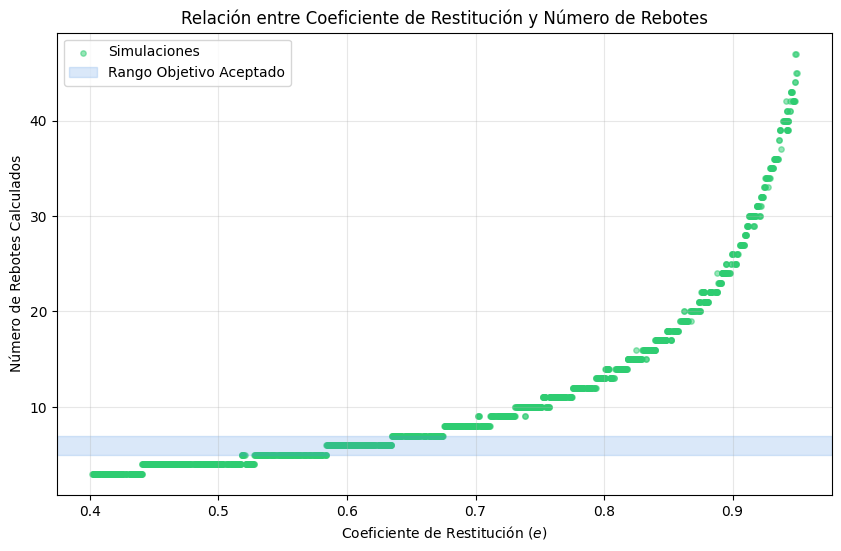

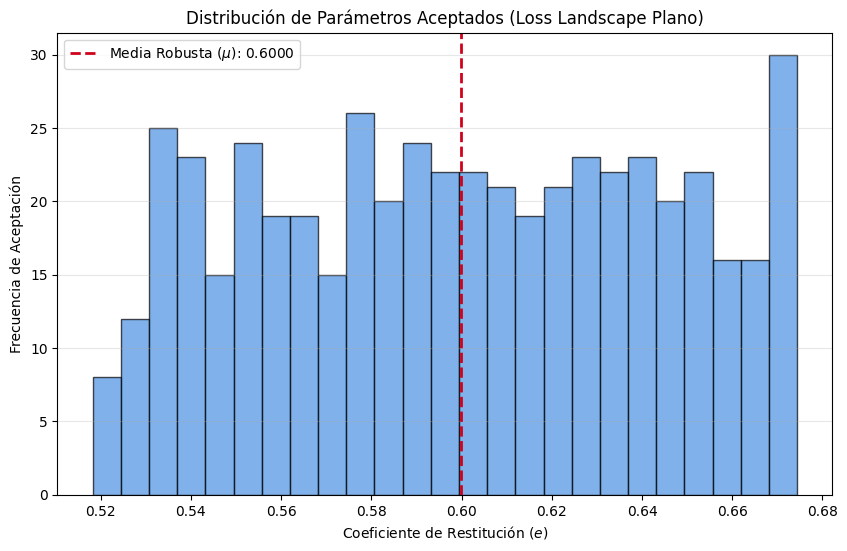

Tamaño de la población aceptada: 507 muestras
Varianza ($\sigma^2$) del valle de aceptación: 0.001905


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def simular_rebotes(e, g=9.81, y0=10.0, dt=0.01, t_max=100.0):
    """
    Simula la trayectoria de una pelota usando integración de Euler.
    Retorna la cantidad de rebotes y el registro temporal de posiciones.
    """
    y, v, t = y0, 0.0, 0.0
    rebotes = 0
    trayectoria = [(t, y)]

    while t < t_max:
        # Integración de Euler
        v_siguiente = v - g * dt
        y_siguiente = y + v_siguiente * dt

        # Detección de colisión con el suelo
        if y_siguiente <= 0:
            y_siguiente = 0
            v_siguiente = -v_siguiente * e

            # Umbral mínimo de velocidad para considerar un rebote válido
            if v_siguiente > 0.5:
                rebotes += 1
            else:
                v_siguiente = 0 # La pelota se detiene

        y, v = y_siguiente, v_siguiente
        t += dt
        trayectoria.append((t, y))

        # Condición de corte temprano si ya se detuvo
        if y == 0 and v == 0:
            break

    return rebotes, trayectoria

# --- Configuración de Montecarlo (Búsqueda Aleatoria) ---
np.random.seed(42)
n_iteraciones = 2000
rebotes_objetivo_min = 5
rebotes_objetivo_max = 7

# Generar población inicial de coeficientes de restitución (e)
e_candidatos = np.random.uniform(0.4, 0.95, n_iteraciones)
e_aceptados = []
todos_los_rebotes = np.zeros(n_iteraciones)

# Filtrado de la población y recolección de datos totales
for i, e in enumerate(e_candidatos):
    rebotes_calculados, _ = simular_rebotes(e)
    todos_los_rebotes[i] = rebotes_calculados
    if rebotes_objetivo_min <= rebotes_calculados <= rebotes_objetivo_max:
        e_aceptados.append(e)

e_aceptados = np.array(e_aceptados)

# Cálculo de la solución robusta y métricas de dispersión
media_e = np.mean(e_aceptados)
varianza_e = np.var(e_aceptados)

# --- Gráfico 1: Relación entre Coeficiente (e) y Rebotes ---
plt.figure(figsize=(10, 6))
plt.scatter(e_candidatos, todos_los_rebotes, alpha=0.5, color='#2ECC71', s=15, label='Simulaciones')
plt.axhspan(rebotes_objetivo_min, rebotes_objetivo_max, color='#4A90E2', alpha=0.2, label='Rango Objetivo Aceptado')
plt.title('Relación entre Coeficiente de Restitución y Número de Rebotes')
plt.xlabel('Coeficiente de Restitución ($e$)')
plt.ylabel('Número de Rebotes Calculados')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Gráfico 2: Análisis Estadístico y Distribución Poblacional ---
plt.figure(figsize=(10, 6))
plt.hist(e_aceptados, bins=25, color='#4A90E2', edgecolor='black', alpha=0.7)

# Marcar la media como el estimador más robusto
plt.axvline(media_e, color='#D0021B', linestyle='dashed', linewidth=2,
            label=f'Media Robusta ($\mu$): {media_e:.4f}')

plt.title('Distribución de Parámetros Aceptados (Loss Landscape Plano)')
plt.xlabel('Coeficiente de Restitución ($e$)')
plt.ylabel('Frecuencia de Aceptación')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Tamaño de la población aceptada: {len(e_aceptados)} muestras")
print(f"Varianza ($\sigma^2$) del valle de aceptación: {varianza_e:.6f}")

# --- Visualización de la Solución Óptima (Animación Minimalista) ---
# Ejecutar la simulación definitiva con el parámetro robusto (la media)
rebotes_finales, trayectoria_optima = simular_rebotes(media_e)
tiempos, alturas = zip(*trayectoria_optima)

# Configuración del lienzo minimalista
fig, ax = plt.subplots(figsize=(4, 6))
ax.set_xlim(-1, 1)
ax.set_ylim(-0.5, max(alturas) * 1.1)
ax.axis('off') # Remover ejes para estilo minimalista

# Dibujar el suelo
ax.axhline(0, color='#333333', lw=3)

# Inicializar la pelota
pelota, = ax.plot([], [], 'o', color='#E67E22', markersize=20)
texto_info = ax.text(0.05, 0.95, '', transform=ax.transAxes, fontsize=10,
                     verticalalignment='top', color='#555555')

def inicializar():
    pelota.set_data([], [])
    texto_info.set_text('')
    return pelota, texto_info

def animar(i):
    # La pelota solo se mueve en Y, X permanece en 0
    pelota.set_data([0], [alturas[i]])
    texto_info.set_text(f"Tiempo: {tiempos[i]:.1f}s\nSolución e: {media_e:.3f}")
    return pelota, texto_info

# Submuestreo de frames para optimizar la carga de la animación
salto_frames = max(1, len(alturas) // 150)
indices_frames = range(0, len(alturas), salto_frames)

animacion = FuncAnimation(fig, animar, frames=indices_frames,
                          init_func=inicializar, blit=True, interval=30)

plt.close(fig) # Previene que se renderice una imagen estática duplicada

# Despliegue interactivo en el notebook
HTML(animacion.to_jshtml())


Varianza

<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:76: SyntaxWarning: invalid escape sequence '\s'
<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:76: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5913/859048505.py:66: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(N_graficables, varianzas_historicas, color='#8E44AD', linewidth=2, label='Varianza Muestral ($\sigma^2$)')
/tmp/ipykernel_5913/859048505.py:76: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Varianza de Parámetros Aceptados ($\sigma^2$)')


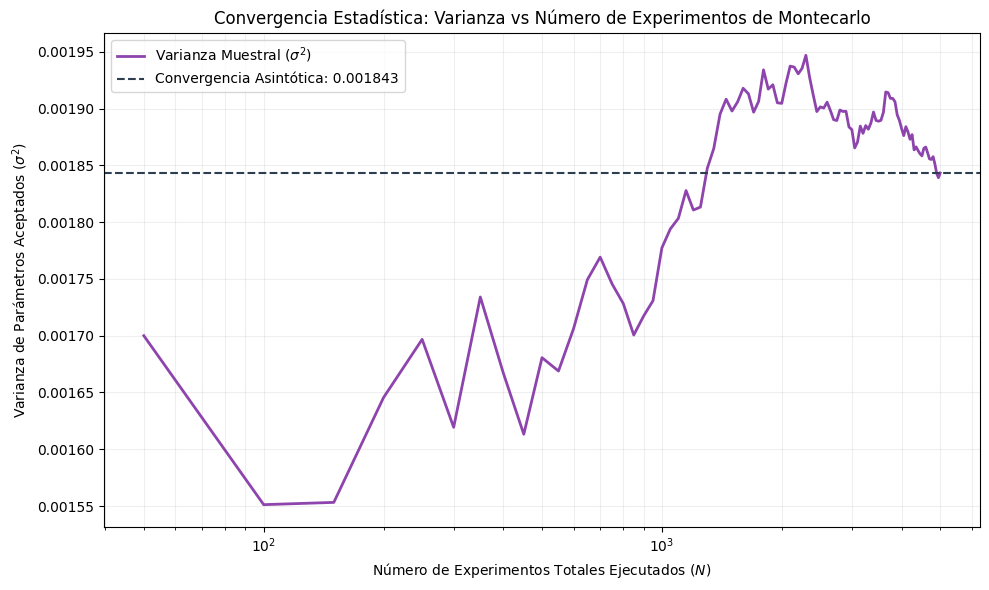

In [6]:

import numpy as np
import matplotlib.pyplot as plt

def simular_rebotes(e, g=9.81, y0=10.0, dt=0.01, t_max=100.0):
    """
    Simula la trayectoria de una pelota.
    Retorna únicamente la cantidad de rebotes para optimizar el cálculo iterativo.
    """
    y, v, t = y0, 0.0, 0.0
    rebotes = 0

    while t < t_max:
        v_siguiente = v - g * dt
        y_siguiente = y + v_siguiente * dt

        if y_siguiente <= 0:
            y_siguiente = 0
            v_siguiente = -v_siguiente * e

            if v_siguiente > 0.5:
                rebotes += 1
            else:
                break # Corte temprano por falta de energía

        y, v = y_siguiente, v_siguiente
        t += dt

    return rebotes

# --- Configuración del Experimento de Convergencia ---
np.random.seed(42)
N_max = 5000       # Número máximo de experimentos a evaluar
paso_N = 50        # Intervalos de muestreo para el eje X
rango_N = np.arange(paso_N, N_max + 1, paso_N)

rebotes_objetivo_min = 5
rebotes_objetivo_max = 7

# Pre-calcular todos los resultados para maximizar la eficiencia computacional
e_candidatos = np.random.uniform(0.4, 0.95, N_max)
rebotes_calculados = np.array([simular_rebotes(e) for e in e_candidatos])

varianzas_historicas = []
N_graficables = []

# Iterar simulando el aumento progresivo de experimentos disponibles
for n in rango_N:
    # Seleccionar el subconjunto de datos hasta la iteración 'n'
    e_parcial = e_candidatos[:n]
    rebotes_parcial = rebotes_calculados[:n]

    # Aplicar el filtro de aceptación
    condicion_aceptacion = (rebotes_parcial >= rebotes_objetivo_min) & (rebotes_parcial <= rebotes_objetivo_max)
    e_aceptados = e_parcial[condicion_aceptacion]

    # Calcular varianza solo si existe una muestra representativa (>1)
    if len(e_aceptados) > 1:
        varianza_actual = np.var(e_aceptados)
        varianzas_historicas.append(varianza_actual)
        N_graficables.append(n)

# --- Visualización de la Convergencia ---
plt.figure(figsize=(10, 6))

# Trazar la curva de aprendizaje / convergencia
plt.plot(N_graficables, varianzas_historicas, color='#8E44AD', linewidth=2, label='Varianza Muestral ($\sigma^2$)')

# Marcar el valor final como aproximación de la asíntota poblacional
if len(varianzas_historicas) > 0:
    varianza_final = varianzas_historicas[-1]
    plt.axhline(varianza_final, color='#2C3E50', linestyle='--',
                label=f'Convergencia Asintótica: {varianza_final:.6f}')

plt.title('Convergencia Estadística: Varianza vs Número de Experimentos de Montecarlo')
plt.xlabel('Número de Experimentos Totales Ejecutados ($N$)')
plt.ylabel('Varianza de Parámetros Aceptados ($\sigma^2$)')
plt.xscale('log') # Escala logarítmica recomendada para observar la fase inicial de alta volatilidad
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()
